# Caregiver Cluster Simple Metrics

This notebook gives a simple, local, decision-oriented summary of the caregiver acceptability project. It uses the project's cached REDCap exports, selected cohort file, configuration, and committed audit tables to answer five practical questions:

1. What REDCap API snapshots and study assets exist locally right now?
2. Which fraud-screening fields, branching-logic audit outputs, and trust-tier summaries actually exist in the current project files?
3. How many selected records are usable for clustering?
4. How balanced and how separated is the two-cluster solution?
5. How different is the held-out screening outcome across clusters?

The notebook stays grounded in current project content. It uses deterministic trust-screen outputs and cached REDCap pulls, avoids unsupported bot-rate claims, and keeps the focus on the study objective: whether the caregiver acceptability profiles remain interpretable and decision-useful.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

from caregiver_analysis_pipeline import (
    CLUSTER_ORDER,
    _screen_summary,
    _verify_sha_sidecar,
    build_cluster_domains,
    fit_named_kmeans,
    load_config,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "data_cache"
OUTPUT_DIR = PROJECT_DIR / "Caregiver Outputs"

if not (PROJECT_DIR / "config.yaml").exists():
    raise FileNotFoundError("Run this notebook from the caregiver-cluster-analysis project folder.")

config = load_config(PROJECT_DIR)
palette = {
    "Higher acceptability": config["figures"]["higher_acceptability"],
    "Conditional acceptability": config["figures"]["conditional_acceptability"],
}
accent = config["figures"]["ink"]

def load_latest_cache(project_id: int, content: str = "record") -> tuple[pd.DataFrame, Path]:
    matches = sorted(CACHE_DIR.glob(f"{project_id}_{content}_*.parquet"))
    if not matches:
        raise FileNotFoundError(f"No cached {content} file found for project {project_id}.")
    path = matches[-1]
    _verify_sha_sidecar(path)
    return pd.read_parquet(path), path

def load_output_table(filename: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / filename)

def load_selected_ids() -> pd.Series:
    selected_path = PROJECT_DIR / "cleaned_autism_study_data.csv"
    selected_column = pd.read_csv(selected_path, nrows=0).columns[0]
    return (
        pd.read_csv(selected_path, usecols=[selected_column])[selected_column]
        .pipe(pd.to_numeric, errors="coerce")
        .dropna()
        .astype(int)
        .astype(str)
    )

## 1. REDCap API Snapshot

This project already contains verified local REDCap API cache files for both studies. The notebook does not assume live API access or fresh token availability. Instead, it inspects the current cached `record`, `metadata`, and `instrument` pulls in `data_cache` and shows which study surfaces and fraud-relevant fields are actually present now.

That matters because the realistic analysis path depends on the available data structure. Timing fields, timestamps, and project-specific anti-fraud fields can be used directly; anything not present should not be inferred or back-filled with speculative methodology.

For the new branching-logic audit, the operative 4581 validation surface is the hashed REDCap cache, not the 2026-01-20 CSV fallback in this folder. The cache contains the full 1,779-row legacy project snapshot needed for the manual audit families.

In [2]:
clean_record, clean_record_path = load_latest_cache(4797, "record")
clean_meta, clean_meta_path = load_latest_cache(4797, "metadata")
clean_instrument, clean_instrument_path = load_latest_cache(4797, "instrument")

dirty_record, dirty_record_path = load_latest_cache(4581, "record")
dirty_meta, dirty_meta_path = load_latest_cache(4581, "metadata")
dirty_instrument, dirty_instrument_path = load_latest_cache(4581, "instrument")

selected_ids = load_selected_ids()
analysis_frame = clean_record.loc[clean_record["record_id"].astype(str).isin(selected_ids)].copy()
analysis_frame["record_id"] = analysis_frame["record_id"].astype(str)
analysis_frame["uid"] = "4797_" + analysis_frame["record_id"]
analysis_frame = analysis_frame.set_index("uid", drop=False)

api_inventory = pd.DataFrame(
    [
        {"source_project": "clean_4797", "content": "record", "rows": len(clean_record), "columns": len(clean_record.columns), "cache_file": clean_record_path.name, "origin": "verified cache"},
        {"source_project": "clean_4797", "content": "metadata", "rows": len(clean_meta), "columns": len(clean_meta.columns), "cache_file": clean_meta_path.name, "origin": "verified cache"},
        {"source_project": "clean_4797", "content": "instrument", "rows": len(clean_instrument), "columns": len(clean_instrument.columns), "cache_file": clean_instrument_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "record", "rows": len(dirty_record), "columns": len(dirty_record.columns), "cache_file": dirty_record_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "metadata", "rows": len(dirty_meta), "columns": len(dirty_meta.columns), "cache_file": dirty_meta_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "instrument", "rows": len(dirty_instrument), "columns": len(dirty_instrument.columns), "cache_file": dirty_instrument_path.name, "origin": "verified cache"},
    ]
)

clean_fields = set(clean_meta["field_name"].astype(str))
dirty_fields = set(dirty_meta["field_name"].astype(str))
metadata_summary = pd.DataFrame(
    [
        {"quantity": "shared metadata fields", "n": len(clean_fields & dirty_fields)},
        {"quantity": "4797-only metadata fields", "n": len(clean_fields - dirty_fields)},
        {"quantity": "4581-only metadata fields", "n": len(dirty_fields - clean_fields)},
    ]
)

def field_exists(frame: pd.DataFrame, field: str) -> str:
    return "Yes" if field in frame.columns else "No"

def prefixed_exists(frame: pd.DataFrame, prefix: str) -> str:
    return "Yes" if any(column.startswith(prefix) for column in frame.columns) else "No"

field_availability = pd.DataFrame(
    [
        {"signal": "All four timing fields", "clean_4797": "Yes" if all(field in clean_record.columns for field in ["get_time_fif", "get_time_val", "get_time_tfa", "get_time_demo"]) else "No", "dirty_4581": "Yes" if all(field in dirty_record.columns for field in ["get_time_fif", "get_time_val", "get_time_tfa", "get_time_demo"]) else "No", "why_it_matters": "Supports direct timing-based quality checks without guessed durations"},
        {"signal": "Timestamp columns", "clean_4797": str(sum(column.endswith("_timestamp") for column in clean_record.columns)), "dirty_4581": str(sum(column.endswith("_timestamp") for column in dirty_record.columns)), "why_it_matters": "Supports burst/submission-window checks when present"},
        {"signal": "age_check_demo", "clean_4797": field_exists(clean_record, "age_check_demo"), "dirty_4581": field_exists(dirty_record, "age_check_demo"), "why_it_matters": "Internal age-consistency fraud screen"},
        {"signal": "elig_knee checkbox set", "clean_4797": prefixed_exists(clean_record, "elig_knee___"), "dirty_4581": prefixed_exists(dirty_record, "elig_knee___"), "why_it_matters": "Project-native attention check"},
        {"signal": "email_elig", "clean_4797": field_exists(clean_record, "email_elig"), "dirty_4581": field_exists(dirty_record, "email_elig"), "why_it_matters": "Possible duplicate/disposable-email screening when returned by API"},
        {"signal": "tfa_free_screen", "clean_4797": field_exists(clean_record, "tfa_free_screen"), "dirty_4581": field_exists(dirty_record, "tfa_free_screen"), "why_it_matters": "Held-out outcome used after clustering"},
    ]
)

project_assets = pd.DataFrame(
    [
        {"role": "Project configuration", "path": "config.yaml"},
        {"role": "Selected cohort file", "path": "cleaned_autism_study_data.csv"},
        {"role": "Clean fallback CSV reference", "path": "InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv"},
        {"role": "Clean fallback labeled CSV", "path": "InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv"},
        {"role": "Current 4797 record cache", "path": f"data_cache/{clean_record_path.name}"},
        {"role": "Current 4581 record cache", "path": f"data_cache/{dirty_record_path.name}"},
        {"role": "Committed row-level audit artifact", "path": "Caregiver Outputs/record_flags.parquet"},
    ]
)

cohort_inventory = pd.DataFrame(
    [
        {"stage": "4797 cached records", "n": len(clean_record), "note": "Verified-clean project snapshot"},
        {"stage": "4581 cached records", "n": len(dirty_record), "note": "Legacy project snapshot used for branching audit validation"},
        {"stage": "Selected analytic records", "n": len(analysis_frame), "note": "Rows matched from cleaned_autism_study_data.csv"},
    ]
)

display(project_assets)
display(api_inventory)
display(metadata_summary)
display(field_availability)
display(cohort_inventory)

,role,path
0,Project configuration,config.yaml
1,Selected cohort file,cleaned_autism_study_data.csv
2,Clean fallback CSV reference,InfantAutismScreenin-FullDataset_DATA_2026-01-...
3,Clean fallback labeled CSV,InfantAutismScreenin-FullDataset_DATA_LABELS_2...
4,Current 4797 record cache,data_cache/4797_record_2026-08-14.parquet
5,Current 4581 record cache,data_cache/4581_record_2026-08-14.parquet
6,Committed row-level audit artifact,Caregiver Outputs/record_flags.parquet


,source_project,content,rows,columns,cache_file,origin
0,clean_4797,record,177,385,4797_record_2026-08-14.parquet,verified cache
1,clean_4797,metadata,324,18,4797_metadata_2026-08-14.parquet,verified cache
2,clean_4797,instrument,5,2,4797_instrument_2026-08-14.parquet,verified cache
3,dirty_4581,record,1779,369,4581_record_2026-08-14.parquet,verified cache
4,dirty_4581,metadata,315,18,4581_metadata_2026-08-14.parquet,verified cache
5,dirty_4581,instrument,5,2,4581_instrument_2026-08-14.parquet,verified cache


,quantity,n
0,shared metadata fields,311
1,4797-only metadata fields,13
2,4581-only metadata fields,4


,signal,clean_4797,dirty_4581,why_it_matters
0,All four timing fields,Yes,Yes,Supports direct timing-based quality checks wi...
1,Timestamp columns,5,5,Supports burst/submission-window checks when p...
2,age_check_demo,Yes,No,Internal age-consistency fraud screen
3,elig_knee checkbox set,Yes,No,Project-native attention check
4,email_elig,Yes,No,Possible duplicate/disposable-email screening ...
5,tfa_free_screen,Yes,Yes,Held-out outcome used after clustering


,stage,n,note
0,4797 cached records,177,Verified-clean project snapshot
1,4581 cached records,1779,Legacy project snapshot used for branching aud...
2,Selected analytic records,135,Rows matched from cleaned_autism_study_data.csv


## 2. Grounded Metric and Fraud Definitions

This notebook keeps the metric set intentionally small and uses only structures that already exist in the project files: cached REDCap pulls, deterministic rule outputs, the selected cohort file, and committed validation tables.

### Domain scaling
For each survey item that belongs in a TFA domain, the existing pipeline rescales responses to 0 to 100:

$$
\text{score}_{0-100} = \frac{x - \min(x)}{\max(x) - \min(x)} \times 100
$$

Reverse-coded items are flipped after scaling so that higher values always mean more of the domain being named.

### Clusterable rule
A selected caregiver enters clustering only if at least 8 of the 10 domain scores are observed:

$$
\text{clusterable} = \mathbb{1}(\text{non-missing domains} \ge 8)
$$

### Deterministic trust tiers
The fraud screen is deterministic and rule-based. It is a grounded screen of current records, not a bot-rate estimator.

$$
\text{Tier 1} = \mathbb{1}(R1 \lor R2 \lor R5 \lor R8 \lor R9)
$$

$$
\text{suspicion count} = R3 + R4 + R6 + R7
$$

Tier 2 means at least two softer suspicion rules fire and Tier 1 does not. Tier 3 means exactly one softer suspicion rule fires and Tier 1 does not. Tier 4 means none of the tier-defining rules fire. Rule R10 is retained as a validation signal, but it is not tier-defining in this project.

### Cluster separation
The main fit-quality metric is the silhouette score:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where $a(i)$ is the mean distance to the respondent's own cluster and $b(i)$ is the mean distance to the nearest other cluster.

### Held-out decision metric
The most decision-useful held-out outcome is the Definitely yes screening rate gap:

$$
\Delta = p_{\text{Higher acceptability}} - p_{\text{Conditional acceptability}}
$$

This remains easy to interpret because screening is not part of the clustering inputs.

## 3. What the Deterministic Fraud Screen Currently Shows

The project already exports a grounded trust screen over all 1,956 cached records. The realistic way to summarize fraud-related evidence here is to show the rule definitions, the rule counts by project, the tier distribution, the rule false-positive rates inside the verified-clean 4797 cohort, and the dedicated branching-logic audit table for the manual 4581 contradiction families.

That keeps the notebook focused on what is actually supported: which records are flagged, how strong the screen is against known-human records, and how much of each project remains in the pass tier. It does **not** try to convert those flags into a literal fraud prevalence.

A concise fraud-case table is also shown for the selected 4797 analytic cohort, limited to Tier 1 and Tier 2 records only. The branching-logic audit case table is kept separate and tied to the hashed 4581 cache because the January CSV in this folder is the clean fallback rather than the full legacy-project extract.

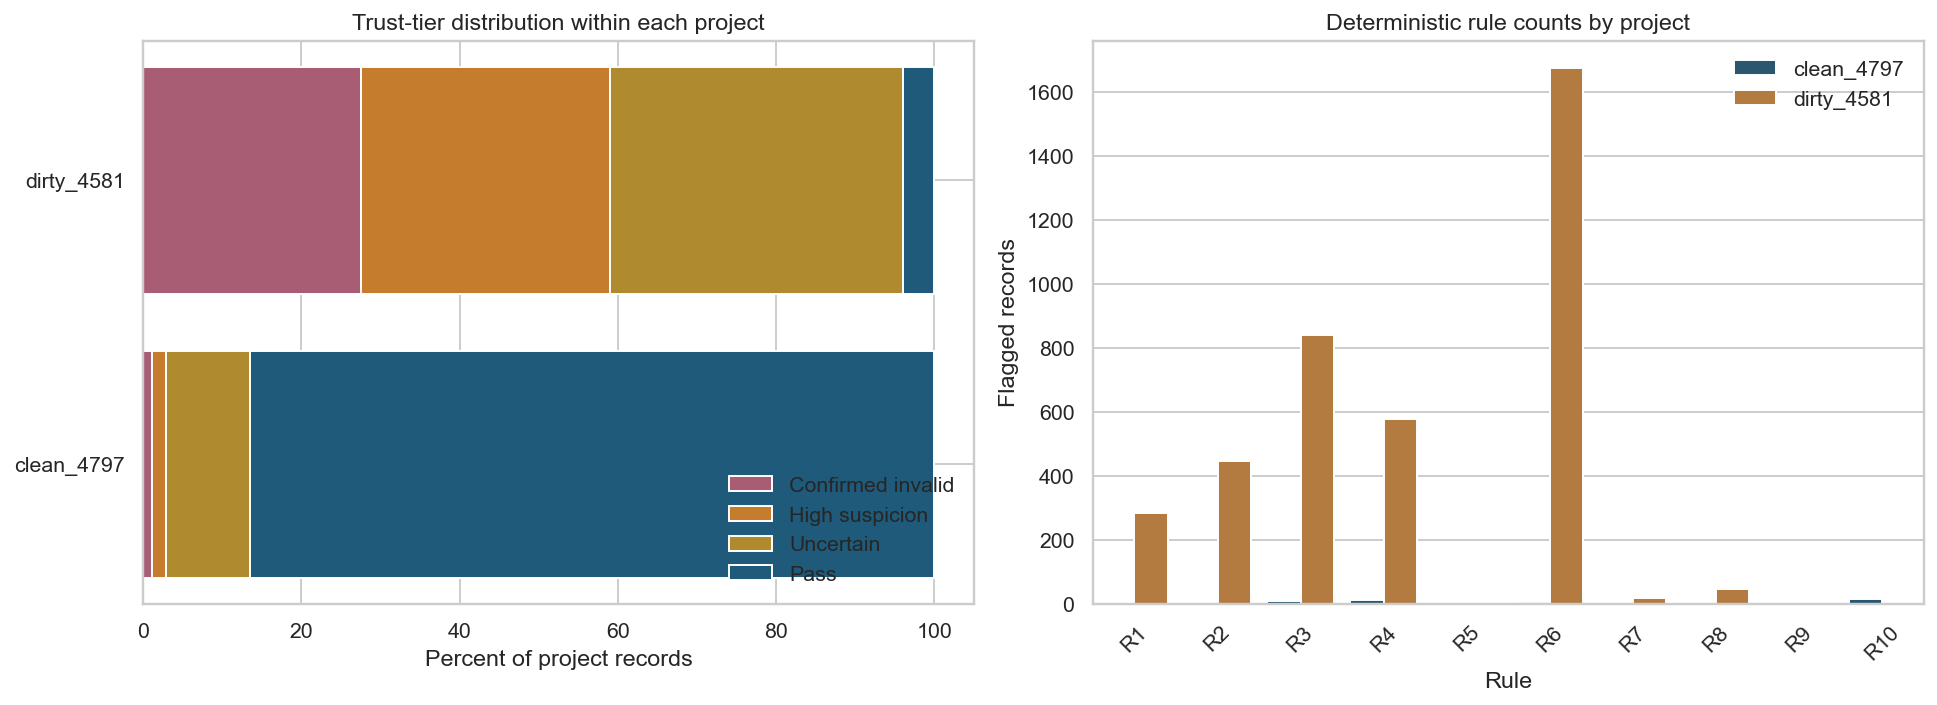

,source_project,Confirmed invalid,High suspicion,Uncertain,Pass,total_n,high_suspicion_or_worse_n,high_suspicion_or_worse_pct
0,clean_4797,2,3,19,153,177,5,2.82
1,dirty_4581,489,560,660,70,1779,1049,58.97


,case_uid,trust_tier,status_quo_cluster,soft_suspicion_rules_n,triggered_rules
100,4797_101,Confirmed invalid,Higher acceptability,0,R9
88,4797_89,Confirmed invalid,Conditional acceptability,0,R9
142,4797_143,High suspicion,Conditional acceptability,2,"R3, R4"


,rule,definition,threshold
0,R1,Total time below verified-human floor,11.57
1,R2,TFA time below verified-human floor,7.85
2,R3,Any instrument below clean 1st percentile,"{""feat_time_demo"": 1.1, ""feat_time_fif"": 0.786..."
3,R4,Within-block response SD at/below clean 1st pe...,"{""feat_sd_likert_4"": 0.777678586912093, ""feat_..."
4,R5,Exact ordered Likert fingerprint duplicate,0.8
5,R6,At least 3 submissions in clean-derived short ...,60.0
6,R7,Near-duplicate open text,0.9
7,R8,Logical family-information inconsistency,logical
8,R9,Impossible demographic combination,logical
9,R10,4797 instrument-native anti-fraud gate (valida...,logical


,rule,flagged_n,false_positive_pct
0,R1,0,0.00
1,R2,0,0.00
2,R3,6,4.58
3,R4,5,3.82
4,R5,0,0.00
5,R6,3,2.29
6,R7,0,0.00
7,R8,0,0.00
8,R9,2,1.53
9,R10,10,7.63


In [3]:
rule_definitions = load_output_table("table_14_fraud_rule_definitions.csv")
false_positive = load_output_table("table_15_rule_false_positive_rates.csv")
rule_counts = load_output_table("table_15b_rule_counts_by_project.csv")
tier_counts = load_output_table("table_16_trust_tier_counts.csv")
record_flags = pd.read_parquet(OUTPUT_DIR / "record_flags.parquet")

fraud_overview = (
    tier_counts.pivot(index="source_project", columns="tier_label", values="n")
    .fillna(0)
    .reset_index()
)
fraud_overview.columns.name = None
fraud_overview["total_n"] = fraud_overview.drop(columns=["source_project"]).sum(axis=1)
fraud_overview["high_suspicion_or_worse_n"] = (
    fraud_overview.get("Confirmed invalid", 0) + fraud_overview.get("High suspicion", 0)
)
fraud_overview["high_suspicion_or_worse_pct"] = (
    fraud_overview["high_suspicion_or_worse_n"] / fraud_overview["total_n"] * 100
)
fraud_overview = fraud_overview[
    [
        "source_project",
        "Confirmed invalid",
        "High suspicion",
        "Uncertain",
        "Pass",
        "total_n",
        "high_suspicion_or_worse_n",
        "high_suspicion_or_worse_pct",
    ]
]

rule_cols = [f"rule_R{i}" for i in range(1, 11)]
selected_uid = {"4797_" + record_id for record_id in selected_ids}
tier12_case_table = (
    record_flags.loc[
        record_flags["uid"].isin(selected_uid) & record_flags["tier"].isin([1, 2]),
        [
            "uid",
            "source_project",
            "tier",
            "tier_label",
            "cluster_status_quo",
            "suspicion_rule_count",
            *rule_cols,
        ],
    ]
    .copy()
    .sort_values(["tier", "uid"])
)
tier12_case_table["triggered_rules"] = tier12_case_table[rule_cols].apply(
    lambda row: ", ".join(
        column.replace("rule_", "") for column, value in row.items() if bool(value)
    ),
    axis=1,
)
tier12_case_table = tier12_case_table[
    [
        "uid",
        "tier_label",
        "cluster_status_quo",
        "suspicion_rule_count",
        "triggered_rules",
    ]
].rename(
    columns={
        "uid": "case_uid",
        "tier_label": "trust_tier",
        "cluster_status_quo": "status_quo_cluster",
        "suspicion_rule_count": "soft_suspicion_rules_n",
    }
)

rule_plot = rule_counts.melt(
    id_vars="rule",
    value_vars=["clean_4797_n", "dirty_4581_n"],
    var_name="source_project",
    value_name="n",
)
rule_plot["source_project"] = rule_plot["source_project"].map(
    {"clean_4797_n": "clean_4797", "dirty_4581_n": "dirty_4581"}
)

tier_order = ["Confirmed invalid", "High suspicion", "Uncertain", "Pass"]
tier_colors = {
    "Confirmed invalid": config["figures"]["pink"],
    "High suspicion": config["figures"]["orange"],
    "Uncertain": config["figures"]["gold"],
    "Pass": config["figures"]["blue"],
}

tier_plot = (
    tier_counts.pivot(index="source_project", columns="tier_label", values="pct_within_project")
    .reindex(index=["clean_4797", "dirty_4581"], columns=tier_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
left = pd.Series(0.0, index=tier_plot.index)
for label in tier_order:
    axes[0].barh(
        tier_plot.index,
        tier_plot[label],
        left=left,
        color=tier_colors[label],
        label=label,
    )
    left = left + tier_plot[label]
axes[0].set_title("Trust-tier distribution within each project")
axes[0].set_xlabel("Percent of project records")
axes[0].legend(frameon=False, loc="lower right")

sns.barplot(
    data=rule_plot,
    x="rule",
    y="n",
    hue="source_project",
    palette={"clean_4797": config["figures"]["blue"], "dirty_4581": config["figures"]["orange"]},
    ax=axes[1],
)
axes[1].set_title("Deterministic rule counts by project")
axes[1].set_xlabel("Rule")
axes[1].set_ylabel("Flagged records")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

display(fraud_overview.round(2))
display(tier12_case_table)
display(rule_definitions[["rule", "definition", "threshold"]])
display(false_positive[["rule", "flagged_n", "false_positive_pct"]].round(2))

### 3a. Branching-Logic Audit Cases

The generalized `R8` rule now writes a dedicated branching-audit table from the hashed REDCap cache. The new prenatal-testing and earlier-diagnosis contradiction families are intentionally scoped to the dirty 4581 audit cohort so they can be reviewed against the manual bot-screen findings without contaminating the verified-clean 4797 human reference.

The summary below focuses on those manual audit families and keeps the older age-band-count `R8` check visible as legacy context rather than mixing it into the manual contradiction counts.

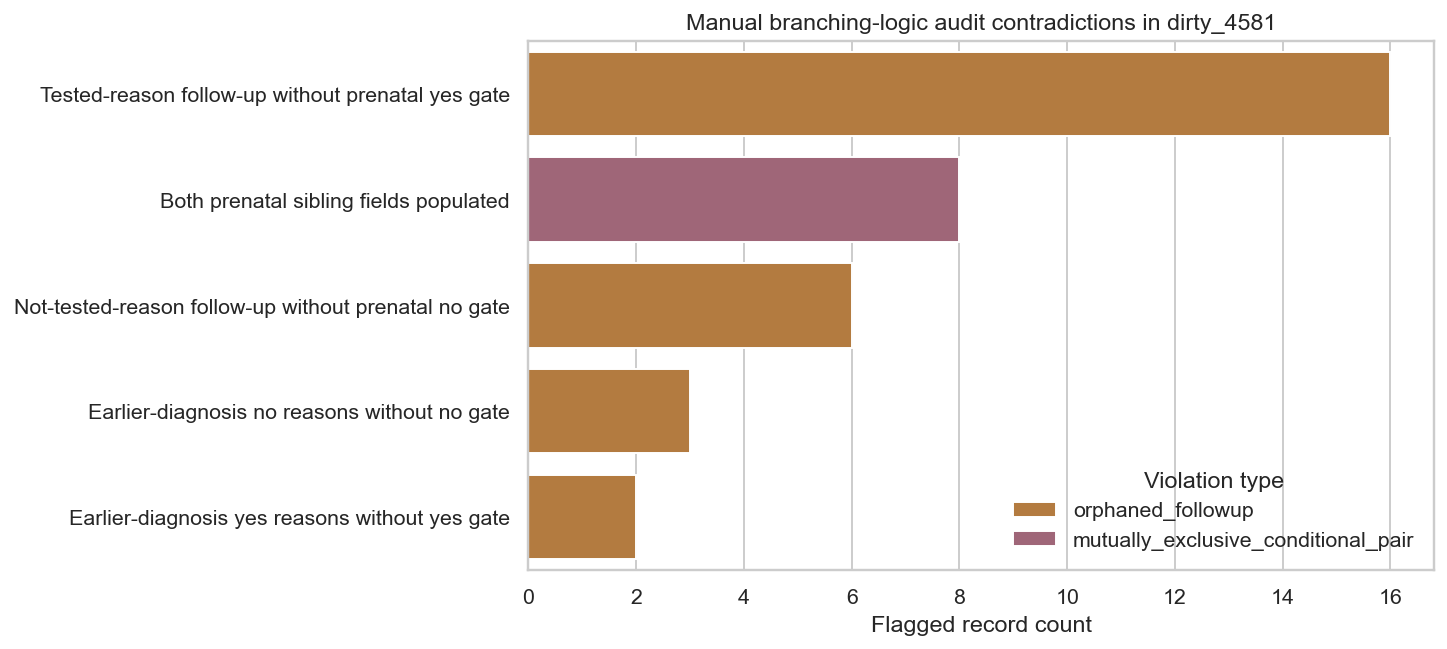

,family_label,violation_type,flagged_records_n
4,Tested-reason follow-up without prenatal yes gate,orphaned_followup,16
0,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,8
3,Not-tested-reason follow-up without prenatal n...,orphaned_followup,6
1,Earlier-diagnosis no reasons without no gate,orphaned_followup,3
2,Earlier-diagnosis yes reasons without yes gate,orphaned_followup,2


,dirty_4581_record_id,audit_family,audit_type,expected_branching_logic,saved_gate_values,saved_conflicting_values
41,31,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
37,118,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
40,273,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
42,571,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
43,768,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
36,1076,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
38,1554,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
39,1699,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
9,1137,Earlier-diagnosis no reasons without no gate,orphaned_followup,"([fif_diag_earlier] <> """" and [fif_diag_earlie...","{""fif_diag_earlier"": ""1""}","{""fif_diag_early_no___1"": ""1"", ""fif_diag_early..."
10,1642,Earlier-diagnosis no reasons without no gate,orphaned_followup,"([fif_diag_earlier] <> """" and [fif_diag_earlie...","{""fif_diag_earlier"": ""1""}","{""fif_diag_early_no___1"": ""0"", ""fif_diag_early..."


,legacy_r8_family,flagged_records_n
0,Legacy R8 age-band count check,9


In [4]:
branching_audit = load_output_table("table_34_branching_logic_audit.csv")
manual_branching_families = [
    "prenatal_testing_mutually_exclusive_pair",
    "prenatal_tested_reason_without_prenatal_yes",
    "prenatal_not_tested_reason_without_prenatal_no",
    "earlier_diagnosis_yes_reason_without_yes_gate",
    "earlier_diagnosis_no_reason_without_no_gate",
]
family_labels = {
    "prenatal_testing_mutually_exclusive_pair": "Both prenatal sibling fields populated",
    "prenatal_tested_reason_without_prenatal_yes": "Tested-reason follow-up without prenatal yes gate",
    "prenatal_not_tested_reason_without_prenatal_no": "Not-tested-reason follow-up without prenatal no gate",
    "earlier_diagnosis_yes_reason_without_yes_gate": "Earlier-diagnosis yes reasons without yes gate",
    "earlier_diagnosis_no_reason_without_no_gate": "Earlier-diagnosis no reasons without no gate",
    "child_age_band_count_exceeds_child_count": "Legacy R8 age-band count check",
}
manual_branching_audit = branching_audit.loc[
    branching_audit["family"].isin(manual_branching_families)
] .copy()
manual_branching_audit["family_label"] = manual_branching_audit["family"].map(family_labels)
branching_summary = (
    manual_branching_audit.groupby(["family_label", "violation_type"], as_index=False)
    .agg(flagged_records_n=("record_id", "nunique"))
    .sort_values(["flagged_records_n", "family_label"], ascending=[False, True])
)
branching_case_table = (
    manual_branching_audit[
        [
            "record_id",
            "family_label",
            "violation_type",
            "gating_logic",
            "gating_values",
            "observed_values",
        ]
    ]
    .rename(
        columns={
            "record_id": "dirty_4581_record_id",
            "family_label": "audit_family",
            "violation_type": "audit_type",
            "gating_logic": "expected_branching_logic",
            "gating_values": "saved_gate_values",
            "observed_values": "saved_conflicting_values",
        }
    )
    .sort_values(["audit_family", "dirty_4581_record_id"])
)
legacy_r8_summary = (
    branching_audit.loc[~branching_audit["family"].isin(manual_branching_families)]
    .groupby("family", as_index=False)
    .agg(flagged_records_n=("record_id", "nunique"))
)
legacy_r8_summary["family"] = legacy_r8_summary["family"].map(family_labels).fillna(legacy_r8_summary["family"])

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.barplot(
    data=branching_summary,
    x="flagged_records_n",
    y="family_label",
    hue="violation_type",
    palette={
        "mutually_exclusive_conditional_pair": config["figures"]["pink"],
        "orphaned_followup": config["figures"]["orange"],
    },
    ax=ax,
)
ax.set_title("Manual branching-logic audit contradictions in dirty_4581")
ax.set_xlabel("Flagged record count")
ax.set_ylabel("")
ax.legend(frameon=False, title="Violation type")
plt.tight_layout()
plt.show()

display(branching_summary)
display(branching_case_table)
if not legacy_r8_summary.empty:
    display(legacy_r8_summary.rename(columns={"family": "legacy_r8_family"}))

## 4. Cluster Metrics on the Selected 4797 Cohort

The remaining sections stay focused on the study objective. After showing what exists in the REDCap caches and what the deterministic trust screen currently flags, the notebook returns to the selected 4797 cohort and summarizes the practical cluster-analysis metrics that are already stable in the project.

In [5]:
fit = fit_named_kmeans(analysis_frame, config)
domains = build_cluster_domains(analysis_frame)
domain_observed_n = domains.notna().sum(axis=1)

screen_table, screen_gap, gap_low, gap_high = _screen_summary(analysis_frame, fit)
cluster_sizes = fit.named_labels.value_counts().reindex(CLUSTER_ORDER)
profile_table = (
    fit.profile_means.T
    .assign(gap=lambda df: df["Higher acceptability"] - df["Conditional acceptability"])
    .sort_values("gap", ascending=False)
)

expected_diag = pd.read_csv(OUTPUT_DIR / "table_3_cluster_diagnostics.csv")
expected_screen = pd.read_csv(OUTPUT_DIR / "table_5_screening_outcome.csv")

validation = pd.DataFrame(
    [
        {"metric": "selected rows", "notebook": len(analysis_frame), "project_export": 135},
        {"metric": "clusterable rows", "notebook": int(fit.eligible.sum()), "project_export": 131},
        {"metric": "higher cluster n", "notebook": int(cluster_sizes["Higher acceptability"]), "project_export": 84},
        {"metric": "conditional cluster n", "notebook": int(cluster_sizes["Conditional acceptability"]), "project_export": 47},
        {
            "metric": "silhouette",
            "notebook": float(fit.silhouette),
            "project_export": float(expected_diag.loc[expected_diag["k"].eq(2), "silhouette"].iloc[0]),
        },
        {
            "metric": "definitely yes gap (pp)",
            "notebook": float(screen_gap),
            "project_export": float(
                expected_screen.loc[expected_screen["cluster"].eq("Higher acceptability"), "definitely_yes_pct"].iloc[0]
                - expected_screen.loc[expected_screen["cluster"].eq("Conditional acceptability"), "definitely_yes_pct"].iloc[0]
            ),
        },
    ]
)
validation["difference"] = validation["notebook"] - validation["project_export"]

metric_summary = pd.DataFrame(
    [
        {"metric": "Clusterable rule", "value": f">= {config['analysis']['minimum_cluster_domains']} of 10 domains observed"},
        {"metric": "Selected analytic rows", "value": len(analysis_frame)},
        {"metric": "Clusterable rows", "value": int(fit.eligible.sum())},
        {"metric": "Clusterable share", "value": f"{fit.eligible.mean() * 100:.1f}%"},
        {"metric": "Higher acceptability n", "value": int(cluster_sizes['Higher acceptability'])},
        {"metric": "Conditional acceptability n", "value": int(cluster_sizes['Conditional acceptability'])},
        {"metric": "Silhouette (k=2)", "value": f"{fit.silhouette:.3f}"},
        {"metric": "Held-out Definitely yes gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% CI", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

display(metric_summary)
display(validation.round(6))

,metric,value
0,Clusterable rule,>= 8 of 10 domains observed
1,Selected analytic rows,135
2,Clusterable rows,131
3,Clusterable share,97.0%
4,Higher acceptability n,84
5,Conditional acceptability n,47
6,Silhouette (k=2),0.180
7,Held-out Definitely yes gap,42.3 percentage points
8,Gap 95% CI,17.5 to 62.0 percentage points


,metric,notebook,project_export,difference
0,selected rows,135.000000,135.000000,0.0
1,clusterable rows,131.000000,131.000000,0.0
2,higher cluster n,84.000000,84.000000,0.0
3,conditional cluster n,47.000000,47.000000,0.0
4,silhouette,0.180263,0.180263,0.0
5,definitely yes gap (pp),42.340426,42.340426,0.0


## 5. Data Readiness

Before looking at cluster differences, the first question is whether enough of the selected cohort has usable TFA-domain data. The two most practical checks are the cohort flow and the distribution of observed domain counts.

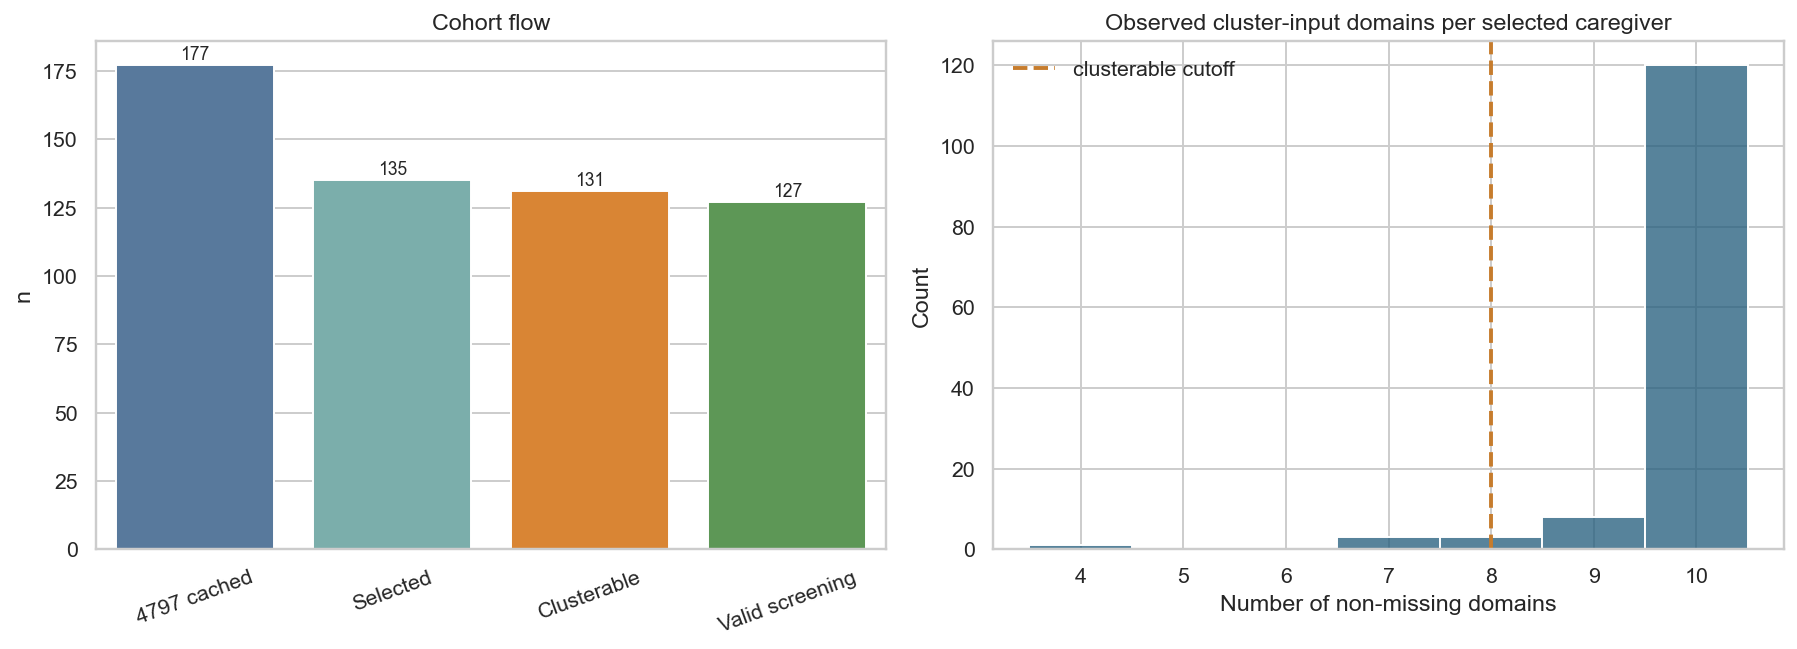

In [6]:
completeness = pd.DataFrame(
    {
        "domains_observed": domain_observed_n,
        "clusterable": domain_observed_n.ge(int(config["analysis"]["minimum_cluster_domains"])),
    }
)

flow_plot = pd.DataFrame(
    [
        {"stage": "4797 cached", "n": len(clean_record)},
        {"stage": "Selected", "n": len(analysis_frame)},
        {"stage": "Clusterable", "n": int(fit.eligible.sum())},
        {"stage": "Valid screening", "n": int(screen_table["valid_n"].sum())},
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(
    data=flow_plot,
    x="stage",
    y="n",
    hue="stage",
    palette=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cohort flow")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
for index, value in enumerate(flow_plot["n"]):
    axes[0].text(index, value + 2, str(value), ha="center", fontsize=9)

sns.histplot(
    data=completeness,
    x="domains_observed",
    discrete=True,
    color=config["figures"]["blue"],
    ax=axes[1],
)
axes[1].axvline(
    config["analysis"]["minimum_cluster_domains"],
    color=config["figures"]["orange"],
    linestyle="--",
    linewidth=2,
    label="clusterable cutoff",
)
axes[1].set_title("Observed cluster-input domains per selected caregiver")
axes[1].set_xlabel("Number of non-missing domains")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 6. Cluster Fit Quality

A simple cluster summary should show three things together: cluster size balance, case-level silhouette spread, and a low-dimensional view of the fitted clusters. The size chart answers whether the split is usable for comparison, the silhouette plot shows how confidently cases sit in their assigned group, and the PCA panel gives a readable geometric view of the same solution.

/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_1019/2315944726.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


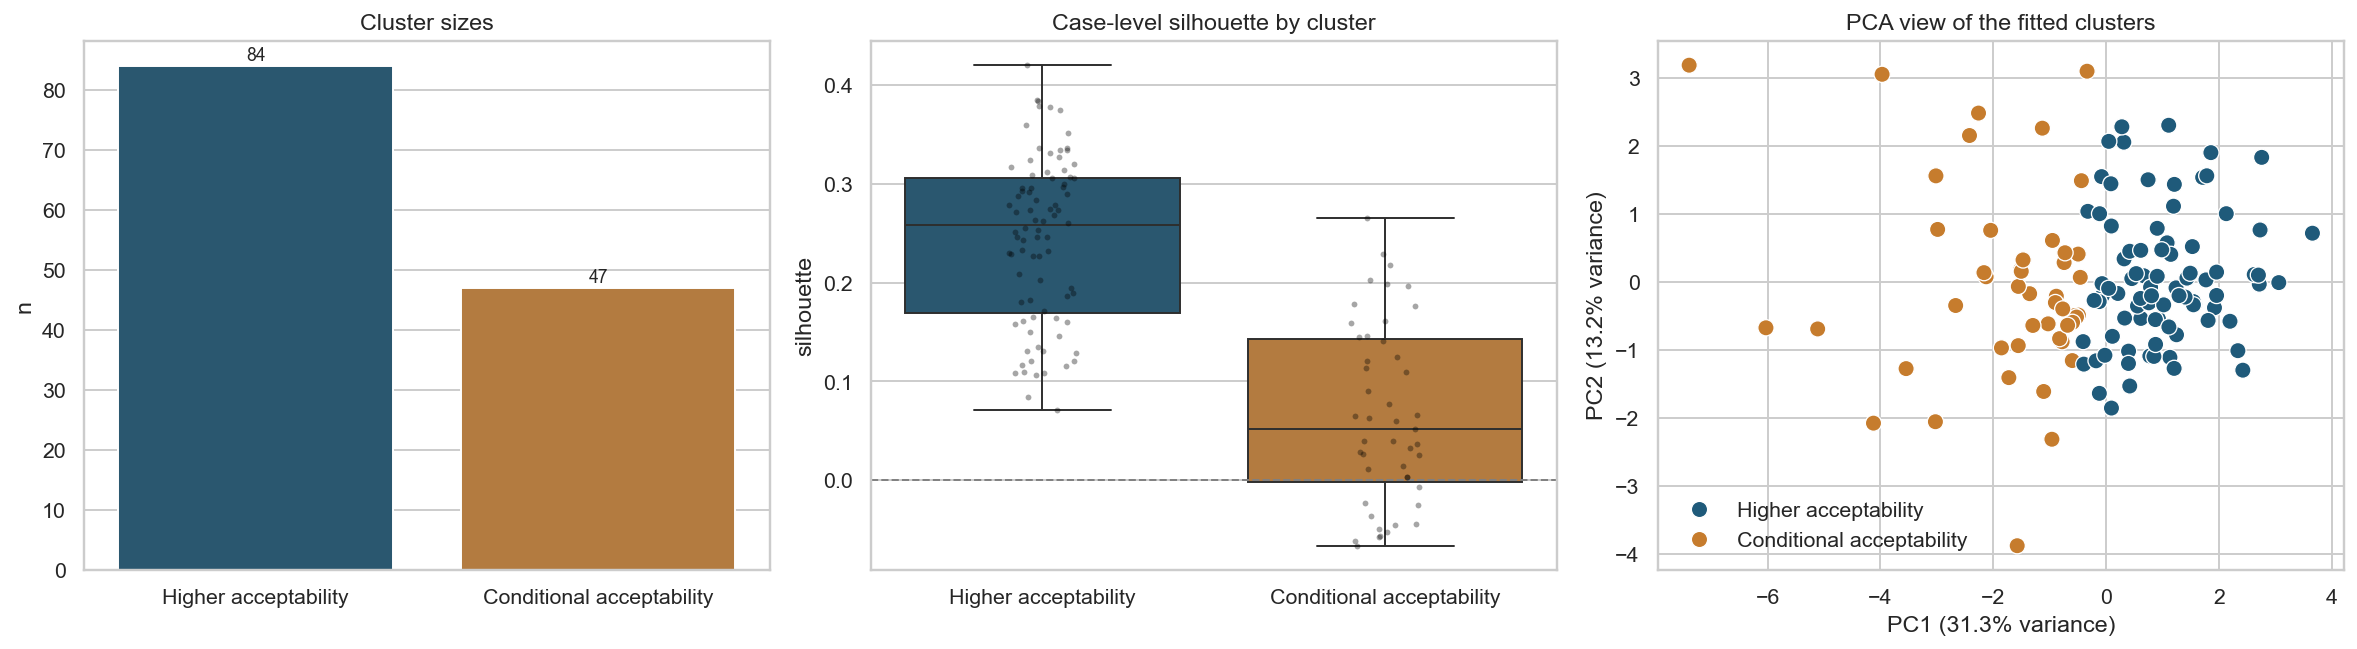

In [7]:
size_table = cluster_sizes.rename_axis("cluster").reset_index(name="n")
silhouette_table = pd.DataFrame(
    {
        "cluster": fit.named_labels.loc[fit.case_silhouette.index].to_numpy(),
        "silhouette": fit.case_silhouette.to_numpy(),
    }
)

pca = PCA(n_components=2, random_state=int(config["analysis"]["seed"]))
pca_scores = pca.fit_transform(fit.X)
pca_table = pd.DataFrame(
    {
        "PC1": pca_scores[:, 0],
        "PC2": pca_scores[:, 1],
        "cluster": fit.named_labels.to_numpy(),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.barplot(
    data=size_table,
    x="cluster",
    y="n",
    hue="cluster",
    palette=palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cluster sizes")
axes[0].set_xlabel("")
for index, value in enumerate(size_table["n"]):
    axes[0].text(index, value + 1, str(value), ha="center", fontsize=9)

sns.boxplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    order=CLUSTER_ORDER,
    palette=palette,
    ax=axes[1],
)
sns.stripplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    order=CLUSTER_ORDER,
    color="black",
    alpha=0.35,
    size=3,
    ax=axes[1],
)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Case-level silhouette by cluster")
axes[1].set_xlabel("")

sns.scatterplot(
    data=pca_table,
    x="PC1",
    y="PC2",
    hue="cluster",
    hue_order=CLUSTER_ORDER,
    palette=palette,
    s=70,
    ax=axes[2],
)
axes[2].set_title("PCA view of the fitted clusters")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Cluster-Defining Domains

The most useful profile summary is the domain-level mean difference between clusters. A simple dumbbell chart makes it clear where the separation is largest without hiding the absolute 0 to 100 scale.

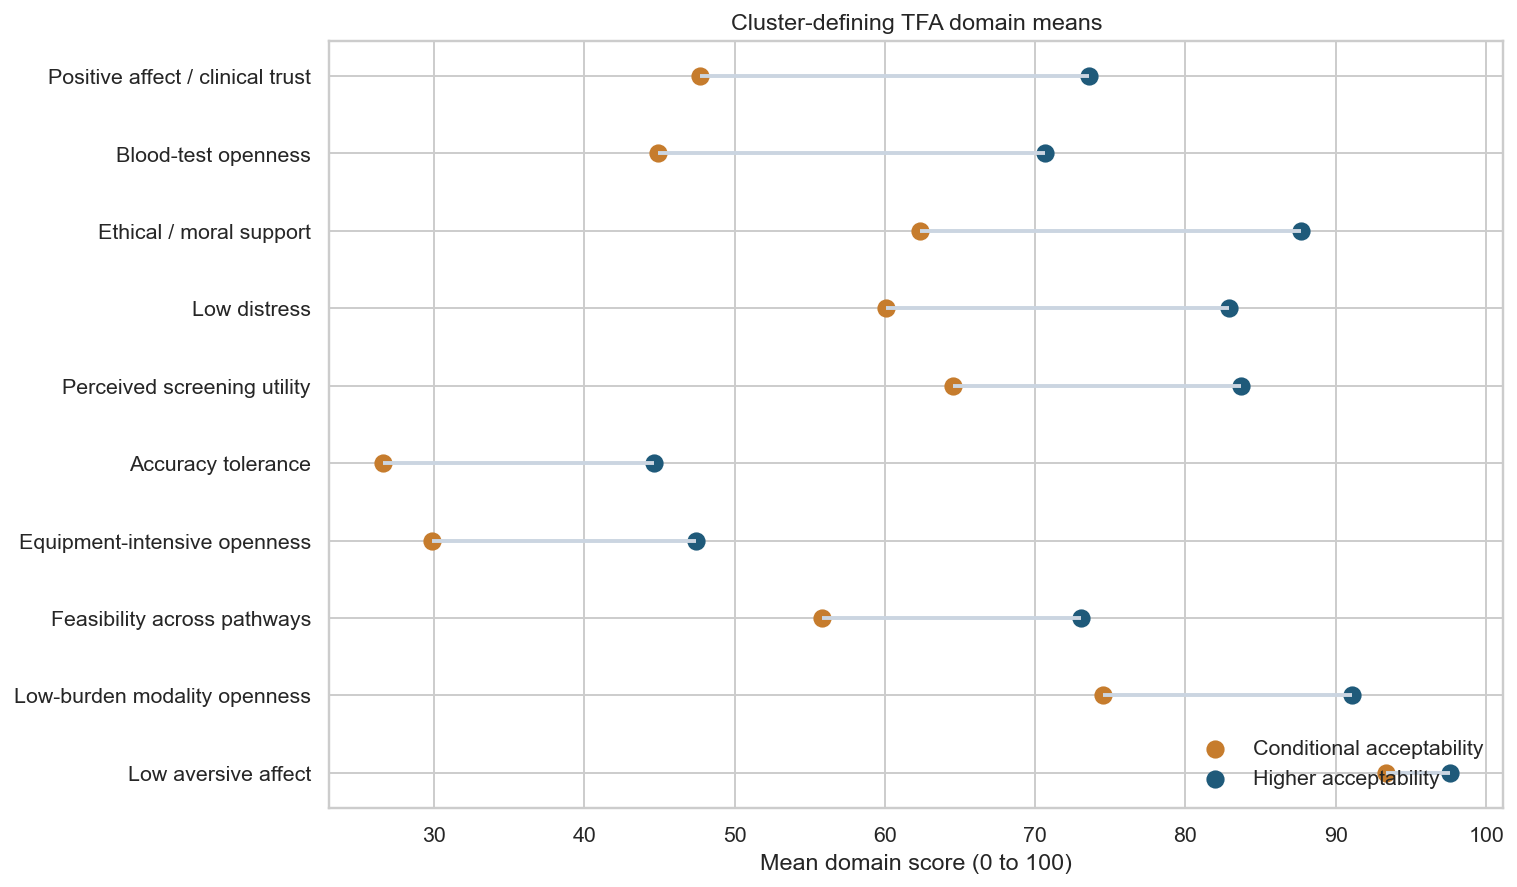

cluster,Higher acceptability,Conditional acceptability,gap
Positive affect / clinical trust,73.6,47.7,25.9
Blood-test openness,70.7,44.9,25.7
Ethical / moral support,87.7,62.3,25.3
Low distress,82.9,60.1,22.8
Perceived screening utility,83.7,64.5,19.2
Accuracy tolerance,44.6,26.6,18.0
Equipment-intensive openness,47.4,29.9,17.5
Feasibility across pathways,73.1,55.8,17.3
Low-burden modality openness,91.1,74.5,16.6
Low aversive affect,97.6,93.4,4.2


In [8]:
plot_table = profile_table.reset_index().rename(columns={"index": "cluster_domain"}).sort_values("gap")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hlines(
    plot_table["cluster_domain"],
    plot_table["Conditional acceptability"],
    plot_table["Higher acceptability"],
    color="#CBD5E1",
    linewidth=2,
)
ax.scatter(
    plot_table["Conditional acceptability"],
    plot_table["cluster_domain"],
    color=palette["Conditional acceptability"],
    s=70,
    label="Conditional acceptability",
)
ax.scatter(
    plot_table["Higher acceptability"],
    plot_table["cluster_domain"],
    color=palette["Higher acceptability"],
    s=70,
    label="Higher acceptability",
)
ax.set_title("Cluster-defining TFA domain means")
ax.set_xlabel("Mean domain score (0 to 100)")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

display(profile_table.round(1))

## 8. Held-Out Screening Outcome

This is the most direct decision metric in the project because the screening response is held out of the clustering inputs. If the two-cluster solution is useful, the gap in Definitely yes rates should be visible without needing extra model layers.

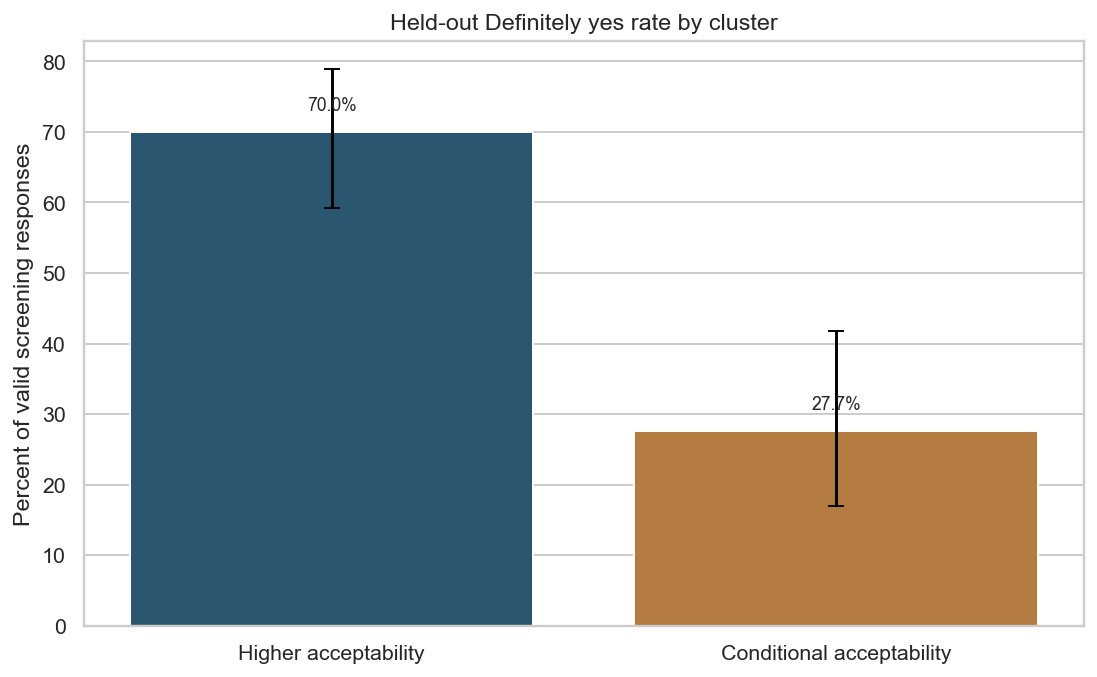

,cluster,valid_n,definitely_yes_n,definitely_yes_pct,wilson_low_pct,wilson_high_pct
0,Higher acceptability,80,56,70.00,59.23,78.94
1,Conditional acceptability,47,13,27.66,16.94,41.76


,metric,value
0,Higher acceptability Definitely yes,70.0% (56/80)
1,Conditional acceptability Definitely yes,27.7% (13/47)
2,Absolute gap,42.3 percentage points
3,Gap 95% interval,17.5 to 62.0 percentage points


In [9]:
screen_plot = screen_table.set_index("cluster").loc[CLUSTER_ORDER].reset_index()
decision_table = pd.DataFrame(
    [
        {"metric": "Higher acceptability Definitely yes", "value": f"{screen_plot.loc[0, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[0, 'definitely_yes_n'])}/{int(screen_plot.loc[0, 'valid_n'])})"},
        {"metric": "Conditional acceptability Definitely yes", "value": f"{screen_plot.loc[1, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[1, 'definitely_yes_n'])}/{int(screen_plot.loc[1, 'valid_n'])})"},
        {"metric": "Absolute gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% interval", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=screen_plot,
    x="cluster",
    y="definitely_yes_pct",
    hue="cluster",
    order=CLUSTER_ORDER,
    palette=palette,
    legend=False,
    ax=ax,
)
for index, row in screen_plot.iterrows():
    lower_error = row["definitely_yes_pct"] - row["wilson_low_pct"]
    upper_error = row["wilson_high_pct"] - row["definitely_yes_pct"]
    ax.errorbar(
        index,
        row["definitely_yes_pct"],
        yerr=[[lower_error], [upper_error]],
        fmt="none",
        ecolor="black",
        capsize=4,
    )
    ax.text(index, row["definitely_yes_pct"] + 3, f"{row['definitely_yes_pct']:.1f}%", ha="center", fontsize=9)
ax.set_title("Held-out Definitely yes rate by cluster")
ax.set_xlabel("")
ax.set_ylabel("Percent of valid screening responses")

plt.tight_layout()
plt.show()

display(screen_plot.round(2))
display(decision_table)

## 9. How To Use These Metrics

1. Use the REDCap API snapshot section to show what is actually present in the current project files before making methodological choices.
2. Use the field-availability table to separate what can be screened directly from what cannot be supported by the available data.
3. Use the trust-tier and rule-count section as the grounded fraud summary; it is more defensible than claiming a literal fraud prevalence.
4. Use cluster size balance and silhouette together: the current split is usable and reasonably balanced, but the silhouette is modest, so the clusters are better treated as practical groupings than hard natural types.
5. Use the domain gap table to explain what separates the clusters in plain language.
6. Use the held-out Definitely yes gap as the main decision metric because it stays outside the clustering inputs and is easy to interpret.
7. Use the validation table to confirm that the notebook still matches the project's committed exports when files are updated.